In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 2ab22ca Add classification results for all 5 transform strategies


# NB9: Phase 2 Summary Plots

Consolidated figures from all Phase 2 experiments. All plots include
error bars (bootstrap 95% CI).

**No GPU required** (~10 min). Loads pre-computed results from `results/phase2/`.

In [2]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import PHASE2_RESULTS_DIR, RESULTS_DIR, print_phase1_summary

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 100,
})

FIGURES_DIR = PHASE2_RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Phase 1 summary
print_phase1_summary()

Total records: 1285
Classified: 666, Filtered: 619
R4 transform: _t64
Label counts:
  ANSWER_LEAKED: 278
  FILTERED: 619
  ILLEGIBLE: 288
  REASONING_LEGIBLE: 100

Per-generator:
  G1: 219 classified (leaked=25%, legible=15%, illegible=60%)
  G2: 218 classified (leaked=69%, legible=17%, illegible=14%)
  G3: 229 classified (leaked=32%, legible=13%, illegible=55%)
  G1 within-Q pairs: 0
  G3 within-Q pairs: 0


In [4]:
# Load all Phase 2 results
results = {}
for name in ['probe_results', 'cka_results', 'attention_results',
             'transition_results', 'reader_analysis_results', 'narration_results']:
    path = PHASE2_RESULTS_DIR / f'{name}.json'
    if path.exists():
        with open(path) as f:
            results[name] = json.load(f)
        print(f"Loaded {name}")
    else:
        print(f"MISSING: {name} -- run the corresponding notebook first")
        results[name] = None

Loaded probe_results
Loaded cka_results
Loaded attention_results
Loaded transition_results
Loaded reader_analysis_results
Loaded narration_results


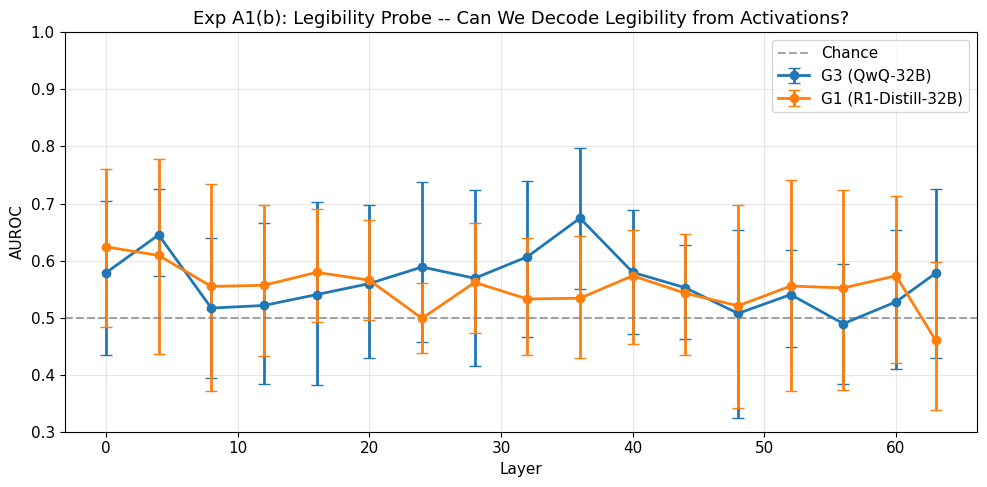

In [5]:
# Figure 1: Legibility Probes (Exp A1b) -- G1 and G3
probe_data = results.get('probe_results')
if probe_data and 'exp_a1b_legibility' in probe_data:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for model_name, color in [('G3', 'C0'), ('G1', 'C1')]:
        model_data = probe_data['exp_a1b_legibility'].get(model_name, {})
        if not model_data:
            continue
        
        layers = sorted(int(k) for k in model_data.keys())
        aurocs = [model_data[str(l)]['auroc'] for l in layers]
        ci_data = [model_data[str(l)].get('auroc_ci', [0.5, 0.5]) for l in layers]
        yerr = [[a - ci[0] for a, ci in zip(aurocs, ci_data)],
                [ci[1] - a for a, ci in zip(aurocs, ci_data)]]
        
        label = {'G3': 'G3 (QwQ-32B)', 'G1': 'G1 (R1-Distill-32B)'}[model_name]
        ax.errorbar(layers, aurocs, yerr=yerr, fmt='o-', capsize=4,
                    label=label, color=color, linewidth=2)
    
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance')
    ax.set_xlabel('Layer')
    ax.set_ylabel('AUROC')
    ax.set_title('Exp A1(b): Legibility Probe -- Can We Decode Legibility from Activations?')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.3, 1.0)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'fig1_legibility_probes.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Probe results not available")

In [6]:
# Figure 1b: Experiment B -- Pre-CoT Illegibility Prediction
probe_data = results.get('probe_results')
if probe_data and 'exp_b_pre_cot' in probe_data:
    exp_b = probe_data['exp_b_pre_cot']
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for model_name, color in [('G1', 'C1'), ('G3', 'C0')]:
        model_data = exp_b.get(model_name, {})
        layer_data = model_data.get('layer_results', {})
        if not layer_data:
            continue
        
        layers = sorted(int(k) for k in layer_data.keys())
        aurocs = [layer_data[str(l)]['auroc'] for l in layers]
        ci_data = [layer_data[str(l)].get('auroc_ci', [0.5, 0.5]) for l in layers]
        yerr = [[a - ci[0] for a, ci in zip(aurocs, ci_data)],
                [ci[1] - a for a, ci in zip(aurocs, ci_data)]]
        
        perm = model_data.get('permutation_test', {})
        p_str = f", p={perm['p_value']:.4f}" if perm else ""
        best = model_data.get('best_auroc', 0)
        label_map = {'G1': 'G1 (R1-Distill-32B)', 'G3': 'G3 (QwQ-32B)'}
        label = f"{label_map[model_name]} (best={best:.3f}{p_str})"
        
        ax.errorbar(layers, aurocs, yerr=yerr, fmt='o-', capsize=4,
                    label=label, color=color, linewidth=2)
    
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance')
    ax.axhline(y=0.65, color='red', linestyle=':', alpha=0.5, label='Threshold (0.65)')
    ax.set_xlabel('Layer')
    ax.set_ylabel('AUROC')
    ax.set_title('Exp B: Pre-CoT Illegibility Prediction (Question-Token Activations)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.3, 1.0)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'fig1b_pre_cot_prediction.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Exp B results not available (run NB03 to generate)")

Exp B results not available (run NB03 to generate)


ValueError: 'yerr' must not contain negative values

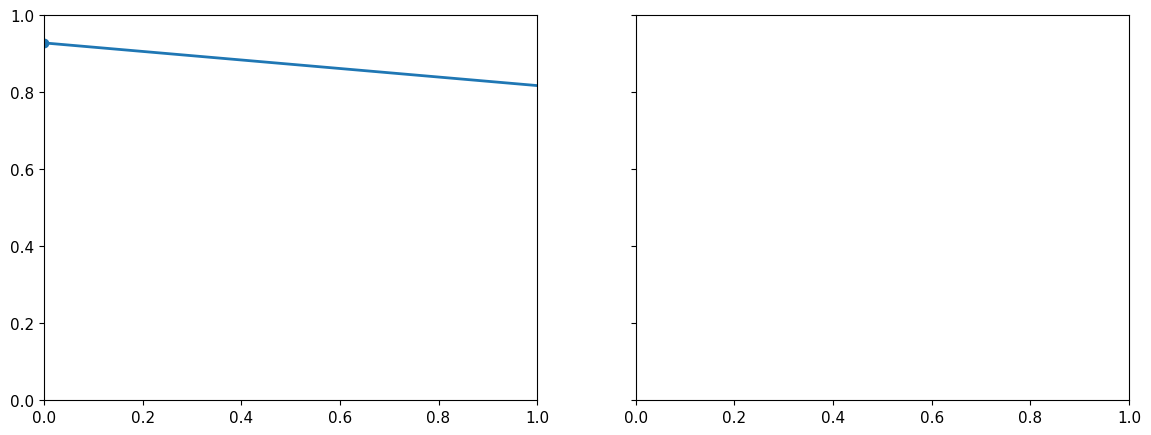

In [7]:
# Figure 2: CKA Geometry (Exp A2)
cka_data = results.get('cka_results')
if cka_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    for ax, model_name in [(axes[0], 'G3'), (axes[1], 'G1')]:
        data = cka_data.get(model_name, {})
        if not data:
            ax.set_title(f'{model_name}: no data')
            continue
        
        layers = sorted(int(k) for k in data.keys())
        cka_vals = [data[str(l)]['cka'] for l in layers]
        ci_data = [data[str(l)].get('cka_ci', [0, 1]) for l in layers]
        yerr = [[v - ci[0] for v, ci in zip(cka_vals, ci_data)],
                [ci[1] - v for v, ci in zip(cka_vals, ci_data)]]
        self_cka = [data[str(l)].get('cka_self_legible', np.nan) for l in layers]
        
        ax.errorbar(layers, cka_vals, yerr=yerr, fmt='o-', capsize=4,
                    label='Legible vs Illegible', linewidth=2)
        ax.plot(layers, self_cka, 's--', alpha=0.6, label='Self-CKA (legible)', linewidth=1.5)
        ax.set_xlabel('Layer')
        title = {'G3': 'G3 (QwQ-32B)', 'G1': 'G1 (R1-Distill)'}[model_name]
        ax.set_title(title)
        ax.legend()
        ax.grid(alpha=0.3)
    
    axes[0].set_ylabel('Linear CKA')
    fig.suptitle('Exp A2: Representational Geometry (CKA)', fontsize=13)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'fig2_cka_geometry.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("CKA results not available")

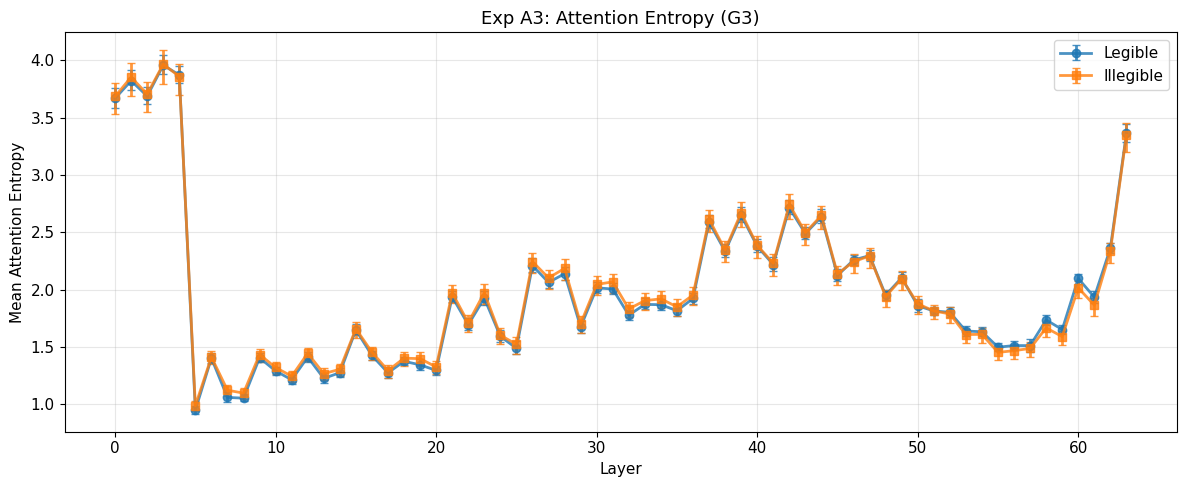

In [8]:
# Figure 3: Attention Entropy (Exp A3) -- with error bars
attn_data = results.get('attention_results')
if attn_data:
    leg_entropy = attn_data['legible_mean_entropy_per_layer']
    ill_entropy = attn_data['illegible_mean_entropy_per_layer']
    layers = range(len(leg_entropy))
    
    # Load per-layer CIs from saved results (computed via bootstrap in NB5)
    leg_ci = attn_data.get('legible_entropy_ci_per_layer')
    ill_ci = attn_data.get('illegible_entropy_ci_per_layer')
    
    # If CIs not in JSON, try loading per-sample arrays for bootstrap
    if leg_ci is None or ill_ci is None:
        leg_npy = PHASE2_RESULTS_DIR / 'legible_attention_entropy.npy'
        ill_npy = PHASE2_RESULTS_DIR / 'illegible_attention_entropy.npy'
        if leg_npy.exists() and ill_npy.exists():
            from phase2_utils import bootstrap_ci_metric
            leg_arr = np.load(leg_npy)
            ill_arr = np.load(ill_npy)
            leg_ci = []
            ill_ci = []
            for l in range(leg_arr.shape[1]):
                _, lo, hi = bootstrap_ci_metric(leg_arr[:, l, :].mean(axis=1))
                leg_ci.append([lo, hi])
                _, lo, hi = bootstrap_ci_metric(ill_arr[:, l, :].mean(axis=1))
                ill_ci.append([lo, hi])
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    if leg_ci is not None and ill_ci is not None:
        leg_yerr = [[leg_entropy[l] - leg_ci[l][0] for l in layers],
                    [leg_ci[l][1] - leg_entropy[l] for l in layers]]
        ill_yerr = [[ill_entropy[l] - ill_ci[l][0] for l in layers],
                    [ill_ci[l][1] - ill_entropy[l] for l in layers]]
        ax.errorbar(list(layers), leg_entropy, yerr=leg_yerr,
                    fmt='o-', capsize=3, label='Legible', linewidth=2, alpha=0.8)
        ax.errorbar(list(layers), ill_entropy, yerr=ill_yerr,
                    fmt='s-', capsize=3, label='Illegible', linewidth=2, alpha=0.8)
    else:
        ax.plot(list(layers), leg_entropy, 'o-', label='Legible', linewidth=2)
        ax.plot(list(layers), ill_entropy, 's-', label='Illegible', linewidth=2)
        print("WARNING: No CI data available for attention entropy plot")
    
    ax.set_xlabel('Layer')
    ax.set_ylabel('Mean Attention Entropy')
    ax.set_title('Exp A3: Attention Entropy (G3)')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'fig3_attention_entropy.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Attention results not available")

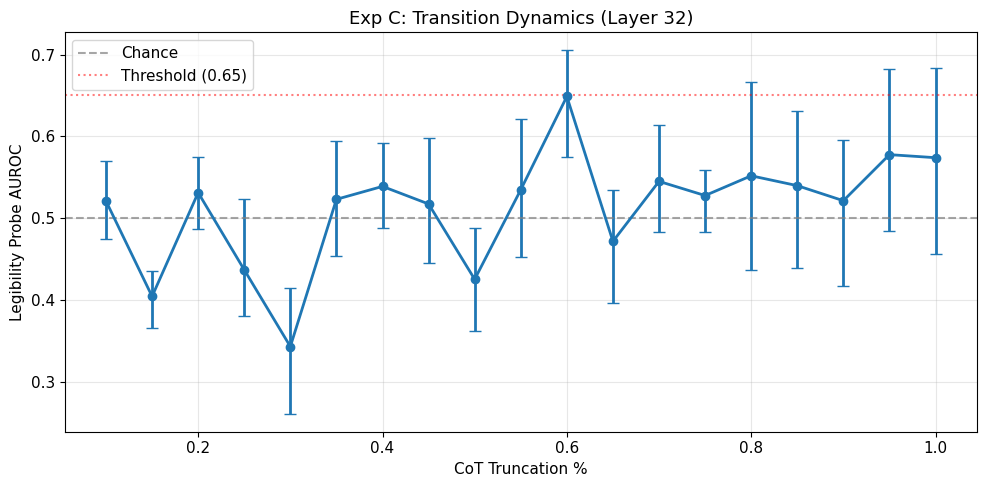

In [9]:
# Figure 4: Transition Dynamics (Exp C)
trans_data = results.get('transition_results')
if trans_data:
    sweep = trans_data['truncation_sweep']
    pcts = [r['pct'] for r in sweep]
    aurocs = [r['auroc'] for r in sweep]
    ci_data = [r.get('auroc_ci', [0.5, 0.5]) for r in sweep]
    yerr = [[a - ci[0] for a, ci in zip(aurocs, ci_data)],
            [ci[1] - a for a, ci in zip(aurocs, ci_data)]]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(pcts, aurocs, yerr=yerr, fmt='o-', capsize=4, linewidth=2)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance')
    ax.axhline(y=0.65, color='red', linestyle=':', alpha=0.5, label='Threshold (0.65)')
    
    t_star = trans_data.get('t_star')
    if t_star:
        ax.axvline(x=t_star, color='green', linestyle=':', alpha=0.5, label=f'T*={t_star:.0%}')
    
    ax.set_xlabel('CoT Truncation %')
    ax.set_ylabel('Legibility Probe AUROC')
    ax.set_title(f'Exp C: Transition Dynamics (Layer {trans_data["sweep_layer"]})')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'fig4_transition.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Transition results not available")

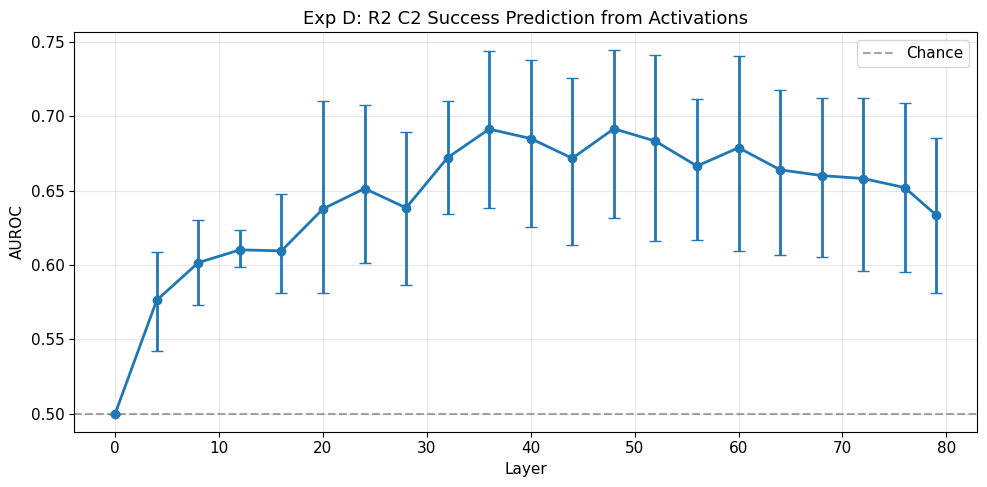

In [10]:
# Figure 5: Reader-Side Analysis (Exp D)
reader_data = results.get('reader_analysis_results')
if reader_data and 'c2_success_probe' in reader_data:
    data = reader_data['c2_success_probe']
    layers = sorted(int(k) for k in data.keys())
    aurocs = [data[str(l)]['auroc'] for l in layers]
    ci_data = [data[str(l)].get('auroc_ci', [0.5, 0.5]) for l in layers]
    yerr = [[a - ci[0] for a, ci in zip(aurocs, ci_data)],
            [ci[1] - a for a, ci in zip(aurocs, ci_data)]]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(layers, aurocs, yerr=yerr, fmt='o-', capsize=4, linewidth=2)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance')
    ax.set_xlabel('Layer')
    ax.set_ylabel('AUROC')
    ax.set_title('Exp D: R2 C2 Success Prediction from Activations')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'fig5_reader_probe.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Reader analysis results not available")

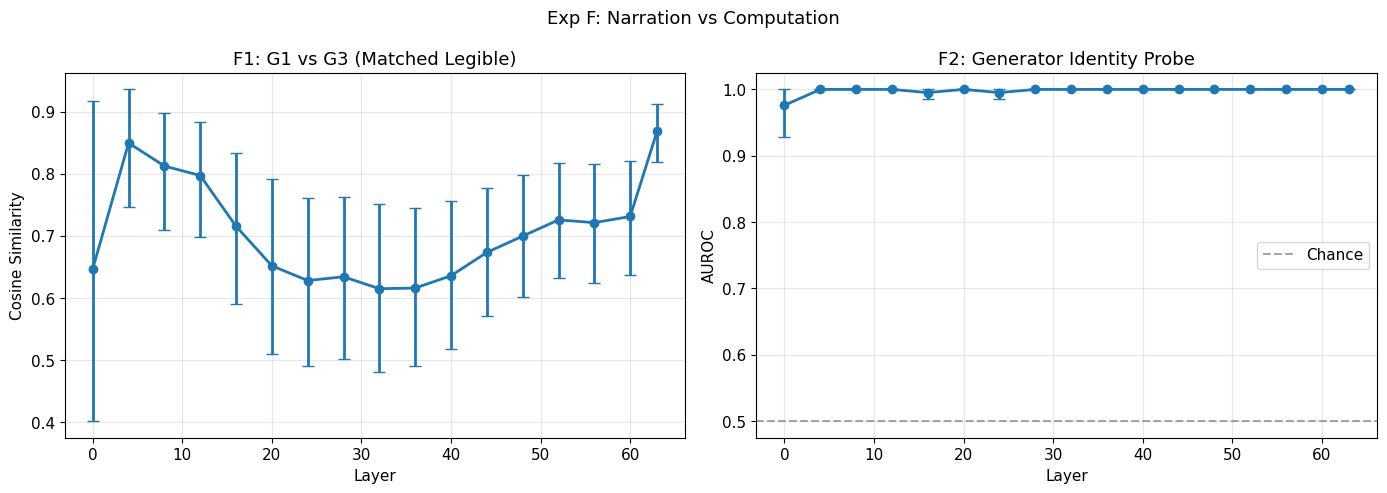

In [11]:
# Figure 6: G1 vs G3 Comparison (Exp F)
narr_data = results.get('narration_results')
if narr_data:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # F1: Cosine similarity
    if 'f1_cosine' in narr_data:
        data = narr_data['f1_cosine']
        layers = sorted(int(k) for k in data.keys())
        cos_vals = [data[str(l)]['mean'] for l in layers]
        ci_data = [data[str(l)].get('ci', [0, 1]) for l in layers]
        yerr = [[v - ci[0] for v, ci in zip(cos_vals, ci_data)],
                [ci[1] - v for v, ci in zip(cos_vals, ci_data)]]
        
        ax1.errorbar(layers, cos_vals, yerr=yerr, fmt='o-', capsize=4, linewidth=2)
        ax1.set_xlabel('Layer')
        ax1.set_ylabel('Cosine Similarity')
        ax1.set_title('F1: G1 vs G3 (Matched Legible)')
        ax1.grid(alpha=0.3)
    
    # F2: Generator identity probe
    if 'f2_generator_probe' in narr_data:
        data = narr_data['f2_generator_probe']
        layers = sorted(int(k) for k in data.keys())
        aurocs = [data[str(l)]['auroc'] for l in layers]
        ci_data = [data[str(l)].get('auroc_ci', [0.5, 0.5]) for l in layers]
        yerr = [[a - ci[0] for a, ci in zip(aurocs, ci_data)],
                [ci[1] - a for a, ci in zip(aurocs, ci_data)]]
        
        ax2.errorbar(layers, aurocs, yerr=yerr, fmt='o-', capsize=4, linewidth=2)
        ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance')
        ax2.set_xlabel('Layer')
        ax2.set_ylabel('AUROC')
        ax2.set_title('F2: Generator Identity Probe')
        ax2.legend()
        ax2.grid(alpha=0.3)
    
    fig.suptitle('Exp F: Narration vs Computation', fontsize=13)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'fig6_narration.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Narration results not available")

In [12]:
# Summary table of key results
print("=" * 70)
print("PHASE 2 SUMMARY")
print("=" * 70)

def get_best(data, metric='auroc'):
    if not data:
        return None, None
    best_k = max(data, key=lambda k: data[k][metric])
    return int(best_k), data[best_k][metric]

if results.get('probe_results'):
    for model in ['G3', 'G1']:
        data = results['probe_results'].get('exp_a1b_legibility', {}).get(model)
        if data:
            layer, auroc = get_best(data)
            print(f"  A1b Legibility Probe ({model}): best layer={layer}, AUROC={auroc:.3f}")

# Experiment B
if results.get('probe_results') and 'exp_b_pre_cot' in results['probe_results']:
    exp_b = results['probe_results']['exp_b_pre_cot']
    for model in ['G1', 'G3']:
        model_data = exp_b.get(model, {})
        if model_data:
            best_layer = model_data.get('best_layer')
            best_auroc = model_data.get('best_auroc', 0)
            perm = model_data.get('permutation_test', {})
            p_str = f"p={perm['p_value']:.4f}" if perm else "p=N/A"
            print(f"  B   Pre-CoT Prediction ({model}): best layer={best_layer}, "
                  f"AUROC={best_auroc:.3f}, {p_str}")

if results.get('transition_results'):
    t_star = results['transition_results'].get('t_star')
    print(f"  C   Transition T*: {t_star}")

if results.get('reader_analysis_results'):
    data = results['reader_analysis_results'].get('c2_success_probe')
    if data:
        layer, auroc = get_best(data)
        print(f"  D   Reader C2 Probe: best layer={layer}, AUROC={auroc:.3f}")

print(f"  E   Truncation Localization: NOT IMPLEMENTED")

if results.get('narration_results'):
    data = results['narration_results'].get('f2_generator_probe')
    if data:
        layer, auroc = get_best(data)
        print(f"  F2  Generator Probe (G1 vs G3): best layer={layer}, AUROC={auroc:.3f}")
    print(f"  F   Note: Compares G1 vs G3 (cross-pipeline), not G1 vs G2 (narration)")

# Attention FDR summary
if results.get('attention_results'):
    fdr_n = results['attention_results'].get('fdr_n_significant', 'N/A')
    print(f"  A3  Attention heads surviving FDR: {fdr_n}")

print("=" * 70)

PHASE 2 SUMMARY
  A1b Legibility Probe (G3): best layer=36, AUROC=0.674
  A1b Legibility Probe (G1): best layer=0, AUROC=0.624
  C   Transition T*: None
  D   Reader C2 Probe: best layer=48, AUROC=0.692
  E   Truncation Localization: NOT IMPLEMENTED
  F2  Generator Probe (G1 vs G3): best layer=4, AUROC=1.000
  F   Note: Compares G1 vs G3 (cross-pipeline), not G1 vs G2 (narration)
  A3  Attention heads surviving FDR: 0
